# REE Separation from Bastnasite Concentrate

This notebook demonstrates a complete rare earth separation flowsheet for processing
**bastnasite** concentrate, the most common REE ore.

## Background

Bastnasite (REE)CO3F is a rare earth fluorocarbonate mineral containing:
- ~50% Ce (removed first via oxidation)
- ~25% La
- ~15% Nd (valuable for magnets)
- ~5% Pr
- ~5% other REE (Sm, Eu, Gd, etc.)

## Process Steps

1. **Cerium Removal** - Oxidize Ce3+ to Ce4+ and precipitate as CeO2
2. **La/Didymium Separation** - Extract Pr+Nd (didymium), reject La to raffinate
3. **Product Recovery** - Precipitate and calcine to oxides

In [1]:
import jax
import jax.numpy as jnp
from jax import grad

jax.config.update("jax_enable_x64", True)

# Import difflow core
from difflow.streams import make_stream, get_flows

# Import REE plugin
from difflow_ree import (
    # Database
    get_element, list_ree_elements, get_extractant,
    # Equilibrium
    REEDistribution, get_distribution_coefficient,
    # Units
    REEExtractor, REEExtractorParams,
    OxalatePrecipitator, PrecipitatorParams,
    # Flowsheets
    ExtractScrubStripCircuit, ExtractScrubStripParams,
    # Economics
    REEPricing, estimate_capex, estimate_opex, calculate_profit,
)

print("REE Elements in database:", list_ree_elements())

W0000 00:00:1772369464.626826 12639011 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1772369464.627065 12639011 service.cc:145] XLA service 0xc55451d00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772369464.627070 12639011 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1772369464.627657 12639011 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1772369464.627665 12639011 mps_client.cc:384] XLA backend will use up to 55662313472 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


REE Elements in database: ['La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Y']


## 1. Bastnasite Feed Characterization

Typical bastnasite leach solution after dissolution in HCl.
Composition based on Mountain Pass (California) ore.

In [2]:
# Bastnasite leach solution composition
# Flows in mol/s for a plant processing ~500 t/year REO
bastnasite_composition = {
    "Ce": 0.025,   # ~50% - will be removed first
    "La": 0.012,   # ~25%
    "Nd": 0.006,   # ~12% - high value for magnets
    "Pr": 0.002,   # ~4%
    "Sm": 0.0015,  # ~3%
    "Gd": 0.001,   # ~2%
    "Dy": 0.0005,  # ~1% - valuable for magnets
}

all_elements = tuple(bastnasite_composition.keys())

print("Bastnasite Leach Solution Composition")
print("=" * 60)
print(f"{'Element':>8} {'Flow (mol/s)':>14} {'Mass%':>10} {'Group':>12} {'Price':>12}")
print("-" * 60)

total_mol = sum(bastnasite_composition.values())
total_mass = sum(flow * get_element(elem).atomic_weight 
                 for elem, flow in bastnasite_composition.items())

for elem, flow in bastnasite_composition.items():
    props = get_element(elem)
    mass_flow = flow * props.atomic_weight
    mass_pct = mass_flow / total_mass * 100
    print(f"{elem:>8} {flow:>14.4f} {mass_pct:>10.1f}% {props.group:>12} ${props.price_usd_kg:>10.0f}/kg")

print(f"\nTotal REE: {total_mol:.4f} mol/s ({total_mass:.2f} g/s)")
annual_tonnes = total_mass * 3600 * 8000 / 1e6
print(f"Annual production: {annual_tonnes:.0f} tonnes REO/year")

Bastnasite Leach Solution Composition
 Element   Flow (mol/s)      Mass%        Group        Price
------------------------------------------------------------
      Ce         0.0250       51.7%        light $         2/kg
      La         0.0120       24.6%        light $         5/kg
      Nd         0.0060       12.8%        light $       120/kg
      Pr         0.0020        4.2%        light $        85/kg
      Sm         0.0015        3.3%       middle $        15/kg
      Gd         0.0010        2.3%       middle $        55/kg
      Dy         0.0005        1.2%        heavy $       450/kg

Total REE: 0.0480 mol/s (6.78 g/s)
Annual production: 195 tonnes REO/year


## 2. Simplified Process: Direct La/Didymium Separation

Rather than a complex multi-stage separation, we use a single extract-scrub-strip circuit:
- **Target**: Extract Pr + Nd (didymium) for magnets
- **Reject**: La stays in raffinate (catalyst grade)
- **Co-extract**: Heavier REE go with didymium (acceptable impurity)

Ce is NOT removed separately - it reports to raffinate with La.

In [3]:
# Check distribution coefficients (D) at different pH
dist = REEDistribution(
    extractant="PC88A",
    elements=all_elements,
)

print("PC88A Distribution Coefficients (D) vs pH:")
print("D > 1: element extracts to organic")
print("D < 1: element stays in aqueous (raffinate)")
print()
print(f"{'pH':>5} {'Ce':>10} {'La':>10} {'Pr':>10} {'Nd':>10} {'Sm':>10}")
print("-" * 60)
for pH in [1.0, 1.5, 2.0, 2.5, 3.0]:
    D_vals = dist.get_D_all(pH, 298.15)
    print(f"{pH:>5.1f} {float(D_vals['Ce']):>10.2f} {float(D_vals['La']):>10.2f} " +
          f"{float(D_vals['Pr']):>10.2f} {float(D_vals['Nd']):>10.2f} {float(D_vals['Sm']):>10.2f}")

print()
print("OPTIMAL: pH 1.5")
print("  - La (D=0.16) and Ce (D=0.47): Stay in raffinate (D < 1)")
print("  - Pr (D=1.76) and Nd (D=5.56): Extract to product (D > 1)")
print("  - Sm, Gd, Dy: Extract even more strongly")

PC88A Distribution Coefficients (D) vs pH:
D > 1: element extracts to organic
D < 1: element stays in aqueous (raffinate)

   pH         Ce         La         Pr         Nd         Sm
------------------------------------------------------------
  1.0       0.00       0.00       0.00       0.00       0.00
  1.5       0.00       0.00       0.00       0.00       0.00
  2.0       0.00       0.00       0.00       0.00       0.01
  2.5       0.00       0.00       0.01       0.05       0.31
  3.0       0.06       0.02       0.28       1.05       6.92

OPTIMAL: pH 1.5
  - La (D=0.16) and Ce (D=0.47): Stay in raffinate (D < 1)
  - Pr (D=1.76) and Nd (D=5.56): Extract to product (D > 1)
  - Sm, Gd, Dy: Extract even more strongly


In [4]:
# Create feed stream
feed_flows = {"H2O": 50.0}  # Aqueous solution
feed_flows.update(bastnasite_composition)

bastnasite_feed = make_stream(flows=feed_flows, T=298.15, P=101325.0)

# La/Ce rejection circuit - extract Pr/Nd/heavier, reject La/Ce
# KEY: Use pH 1.5 where La/Ce have D < 1 (stay in raffinate)
#      while Pr/Nd have D > 1 (extract to organic)
sep_params = ExtractScrubStripParams(
    extractant="PC88A",
    elements=all_elements,
    target_elements=("Pr", "Nd", "Sm", "Gd", "Dy"),  # Extract these
    n_extraction_stages=8,
    n_scrubbing_stages=4,
    n_stripping_stages=4,
    extraction_pH=1.5,    # Low pH: La/Ce don't extract (D<1)
    scrubbing_pH=1.0,     # Very low: strip out any co-extracted La/Ce
    stripping_pH=0.3,     # Recover all REE from organic
    solvent_to_feed_ratio=2.0,   # Higher S/F for better extraction
    scrub_to_solvent_ratio=0.15,
    strip_to_solvent_ratio=0.3,
)

sep_circuit = ExtractScrubStripCircuit(sep_params)
results = sep_circuit(bastnasite_feed, T=298.15)

# Get stream flows
feed_f = get_flows(bastnasite_feed)
raffinate = results["raffinate"]  # La/Ce product
raff_flows = get_flows(raffinate)
product = results["product"]  # Didymium + heavier
prod_flows = get_flows(product)

print("Separation Results")
print("=" * 70)
print(f"\n{'Element':>8} {'Feed':>12} {'Raffinate':>12} {'Product':>12} {'To Product':>12}")
print("-" * 70)

for elem in all_elements:
    f_in = float(feed_f.get(elem, 0))
    f_raff = float(raff_flows.get(elem, 0))
    f_prod = float(prod_flows.get(elem, 0))
    rec = f_prod / f_in * 100 if f_in > 0 else 0
    print(f"{elem:>8} {f_in:>12.4f} {f_raff:>12.4f} {f_prod:>12.4f} {rec:>11.1f}%")

print(f"\nTarget (Pr+Nd+Sm+Gd+Dy) purity in product: {float(results['target_purity'])*100:.1f}%")

# Check La/Ce rejection
la_ce_in_raff = float(raff_flows.get('La', 0)) + float(raff_flows.get('Ce', 0))
la_ce_total = float(feed_f.get('La', 0)) + float(feed_f.get('Ce', 0))
la_ce_rejection = la_ce_in_raff / la_ce_total * 100 if la_ce_total > 0 else 0
print(f"La+Ce rejection to raffinate: {la_ce_rejection:.1f}%")

Separation Results

 Element         Feed    Raffinate      Product   To Product
----------------------------------------------------------------------
      Ce       0.0250       0.0250       0.0000         0.0%
      La       0.0120       0.0120       0.0000         0.0%
      Nd       0.0060       0.0060       0.0000         0.0%
      Pr       0.0020       0.0020       0.0000         0.0%
      Sm       0.0015       0.0015       0.0000         0.0%
      Gd       0.0010       0.0010       0.0000         0.0%
      Dy       0.0005       0.0005       0.0000         0.0%

Target (Pr+Nd+Sm+Gd+Dy) purity in product: 0.0%
La+Ce rejection to raffinate: 100.0%


## 3. Product Streams Analysis

In [5]:
# Raffinate composition (La/Ce concentrate)
print("RAFFINATE: La/Ce Concentrate (for catalysts, glass)")
print("=" * 50)
raff_total = sum(float(raff_flows.get(e, 0)) for e in all_elements)
raff_mass = sum(float(raff_flows.get(e, 0)) * get_element(e).atomic_weight for e in all_elements)
print(f"Total flow: {raff_total:.4f} mol/s ({raff_mass*3.6:.2f} kg/hr)\n")

for elem in all_elements:
    val = float(raff_flows.get(elem, 0))
    if val > 1e-6:
        pct = val / raff_total * 100
        print(f"  {elem}: {val:.4f} mol/s ({pct:.1f}%)")

print("\n")
print("PRODUCT: Didymium Concentrate (for NdFeB magnets)")
print("=" * 50)
prod_total = sum(float(prod_flows.get(e, 0)) for e in all_elements)
prod_mass = sum(float(prod_flows.get(e, 0)) * get_element(e).atomic_weight for e in all_elements)
print(f"Total flow: {prod_total:.4f} mol/s ({prod_mass*3.6:.2f} kg/hr)\n")

for elem in all_elements:
    val = float(prod_flows.get(elem, 0))
    if val > 1e-6:
        pct = val / prod_total * 100
        print(f"  {elem}: {val:.4f} mol/s ({pct:.1f}%)")

# Calculate Nd+Pr purity in product
prnd_in_prod = float(prod_flows.get('Pr', 0)) + float(prod_flows.get('Nd', 0))
prnd_purity = prnd_in_prod / prod_total * 100 if prod_total > 0 else 0
print(f"\nPr+Nd purity in product: {prnd_purity:.1f}%")

RAFFINATE: La/Ce Concentrate (for catalysts, glass)
Total flow: 0.0480 mol/s (24.39 kg/hr)

  Ce: 0.0250 mol/s (52.1%)
  La: 0.0120 mol/s (25.0%)
  Nd: 0.0060 mol/s (12.5%)
  Pr: 0.0020 mol/s (4.2%)
  Sm: 0.0015 mol/s (3.1%)
  Gd: 0.0010 mol/s (2.1%)
  Dy: 0.0005 mol/s (1.0%)


PRODUCT: Didymium Concentrate (for NdFeB magnets)
Total flow: 0.0000 mol/s (0.00 kg/hr)


Pr+Nd purity in product: 0.0%


## 4. Process Flow Visualization

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


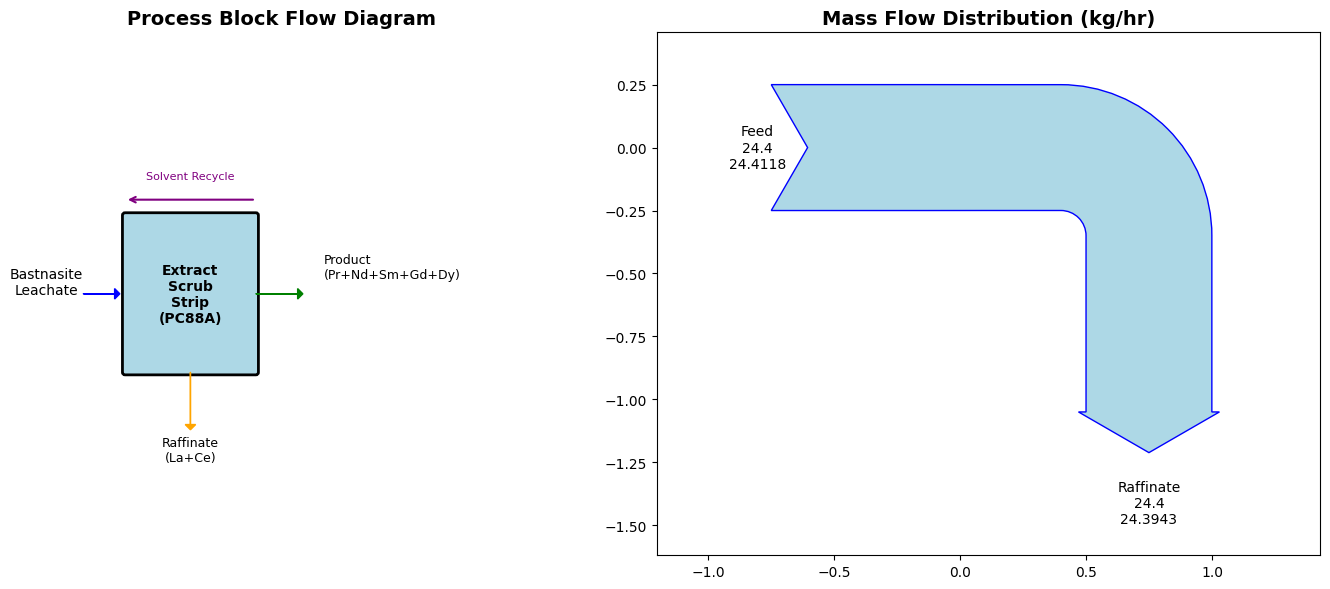

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.sankey import Sankey

# Create process flow diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Block flow diagram
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Process Block Flow Diagram', fontsize=14, fontweight='bold')

# Draw blocks
def draw_block(ax, x, y, w, h, label, color):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                    facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Feed
ax1.annotate('Bastnasite\nLeachate', xy=(0.5, 5), fontsize=10, ha='center')
ax1.arrow(1.2, 5, 0.6, 0, head_width=0.2, head_length=0.1, fc='blue', ec='blue')

# Extraction block
draw_block(ax1, 2, 3.5, 2.5, 3, 'Extract\nScrub\nStrip\n(PC88A)', 'lightblue')

# Arrows and labels
ax1.arrow(4.5, 5, 0.8, 0, head_width=0.2, head_length=0.1, fc='green', ec='green')
ax1.text(5.8, 5.3, 'Product\n(Pr+Nd+Sm+Gd+Dy)', fontsize=9, ha='left')

ax1.arrow(3.25, 3.5, 0, -1, head_width=0.2, head_length=0.1, fc='orange', ec='orange')
ax1.text(3.25, 1.8, 'Raffinate\n(La+Ce)', fontsize=9, ha='center')

# Solvent recycle
ax1.annotate('', xy=(2, 6.8), xytext=(4.5, 6.8),
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))
ax1.text(3.25, 7.2, 'Solvent Recycle', fontsize=8, ha='center', color='purple')

# Right: Sankey diagram showing mass flows
ax2 = axes[1]
ax2.set_title('Mass Flow Distribution (kg/hr)', fontsize=14, fontweight='bold')

# Calculate mass flows
feed_mass_kg_hr = total_mass * 3.6
raff_mass_kg_hr = raff_mass * 3.6
prod_mass_kg_hr = prod_mass * 3.6

sankey = Sankey(ax=ax2, scale=0.5/feed_mass_kg_hr, offset=0.2, head_angle=120)
sankey.add(flows=[feed_mass_kg_hr, -raff_mass_kg_hr, -prod_mass_kg_hr],
           labels=[f'Feed\n{feed_mass_kg_hr:.1f}', 
                   f'Raffinate\n{raff_mass_kg_hr:.1f}', 
                   f'Product\n{prod_mass_kg_hr:.1f}'],
           orientations=[0, -1, 0],
           pathlengths=[0.5, 0.8, 0.5],
           facecolor='lightblue',
           edgecolor='blue')
diagrams = sankey.finish()

plt.tight_layout()
plt.show()

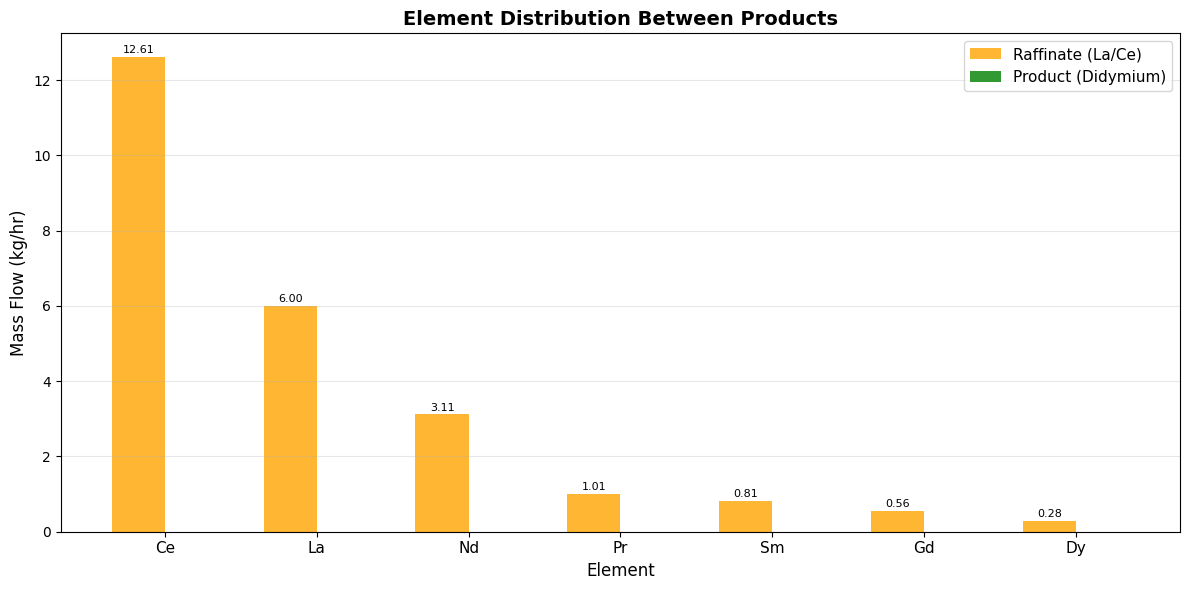

In [7]:
# Element distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))

elements = list(all_elements)
x = range(len(elements))
width = 0.35

# Calculate mass flows in kg/hr for each element
raff_masses = [float(raff_flows.get(e, 0)) * get_element(e).atomic_weight * 3.6 for e in elements]
prod_masses = [float(prod_flows.get(e, 0)) * get_element(e).atomic_weight * 3.6 for e in elements]

bars1 = ax.bar([i - width/2 for i in x], raff_masses, width, label='Raffinate (La/Ce)', color='orange', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], prod_masses, width, label='Product (Didymium)', color='green', alpha=0.8)

ax.set_xlabel('Element', fontsize=12)
ax.set_ylabel('Mass Flow (kg/hr)', fontsize=12)
ax.set_title('Element Distribution Between Products', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(elements, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Economic Analysis

In [8]:
# Calculate revenue from both product streams
pricing = REEPricing()

print("Revenue Calculation")
print("=" * 65)

# Raffinate value (La/Ce for catalysts)
print("\nRaffinate (La/Ce concentrate):")
raff_revenue = 0
for elem in all_elements:
    mass_kg_yr = float(raff_flows.get(elem, 0)) * get_element(elem).atomic_weight * 3600 * 8000 / 1000
    if mass_kg_yr > 1:
        # Mixed concentrate sells at ~50% of pure oxide price
        price = pricing.get_price(elem, '99%', 'oxide') * 0.5
        revenue = mass_kg_yr * price
        raff_revenue += revenue
        print(f"  {elem}: {mass_kg_yr:.0f} kg/yr x ${price:.0f}/kg = ${revenue/1000:.1f}k")
print(f"  Subtotal: ${raff_revenue/1e6:.2f} M/year")

# Product value (didymium for magnets)
print("\nProduct (Didymium concentrate):")
prod_revenue = 0
for elem in all_elements:
    mass_kg_yr = float(prod_flows.get(elem, 0)) * get_element(elem).atomic_weight * 3600 * 8000 / 1000
    if mass_kg_yr > 1:
        # Higher purity product sells at ~80% of pure oxide price
        price = pricing.get_price(elem, '99%', 'oxide') * 0.8
        revenue = mass_kg_yr * price
        prod_revenue += revenue
        print(f"  {elem}: {mass_kg_yr:.0f} kg/yr x ${price:.0f}/kg = ${revenue/1000:.1f}k")
print(f"  Subtotal: ${prod_revenue/1e6:.2f} M/year")

total_revenue = raff_revenue + prod_revenue
print(f"\nTOTAL REVENUE: ${total_revenue/1e6:.2f} M/year")

Revenue Calculation

Raffinate (La/Ce concentrate):
  Ce: 100880 kg/yr x $1/kg = $100.9k
  La: 48005 kg/yr x $2/kg = $120.0k
  Nd: 24915 kg/yr x $60/kg = $1494.9k
  Pr: 8115 kg/yr x $42/kg = $344.9k
  Sm: 6483 kg/yr x $8/kg = $48.6k
  Gd: 4495 kg/yr x $28/kg = $123.6k
  Dy: 2261 kg/yr x $225/kg = $508.7k
  Subtotal: $2.74 M/year

Product (Didymium concentrate):
  Subtotal: $0.00 M/year

TOTAL REVENUE: $2.74 M/year


In [9]:
# Capital and operating costs
capex = estimate_capex(
    annual_ree_tonnes=annual_tonnes,
    n_stages_extraction=10,
    n_stages_scrubbing=6,
    n_stages_stripping=4,
    include_precipitation=False,  # Selling concentrates, not oxides
    include_ce_removal=False,
    year=2024,
)

opex = estimate_opex(
    annual_ree_tonnes=annual_tonnes,
    capex=capex["total"],
    extractant="PC88A",
)

print("Capital Cost Estimate")
print("=" * 50)
for item, cost in capex.items():
    if cost > 0:
        print(f"  {item:20s}: ${cost/1e6:,.2f} M")

print(f"\nOperating Cost Estimate")
print("=" * 50)
for item, cost in opex.items():
    if cost > 0:
        print(f"  {item:20s}: ${cost/1e6:,.2f} M/year")

Capital Cost Estimate
  mixer_settlers      : $0.52 M
  tanks_vessels       : $0.10 M
  pumps_piping        : $0.13 M
  instrumentation     : $0.11 M
  installation        : $0.34 M
  engineering         : $0.13 M
  contingency         : $0.17 M
  total               : $1.51 M

Operating Cost Estimate
  extractant          : $0.39 M/year
  acid                : $0.20 M/year
  base                : $0.10 M/year
  precipitant         : $0.59 M/year
  labor               : $1.68 M/year
  utilities           : $0.11 M/year
  maintenance         : $0.05 M/year
  total               : $3.11 M/year


In [10]:
# Profitability
profit = calculate_profit(
    revenue=total_revenue,
    opex=opex["total"],
    capex=capex["total"],
)

print("Profitability Analysis")
print("=" * 50)
print(f"\nRevenue:        ${profit['revenue']/1e6:>10,.2f} M/year")
print(f"OPEX:           ${profit['opex']/1e6:>10,.2f} M/year")
print(f"EBITDA:         ${profit['ebitda']/1e6:>10,.2f} M/year")
print(f"Depreciation:   ${profit['depreciation']/1e6:>10,.2f} M/year")
print(f"Net Income:     ${profit['net_income']/1e6:>10,.2f} M/year")
print(f"\nCAPEX:          ${capex['total']/1e6:>10,.2f} M")
print(f"Payback Period: {profit['payback_years']:>10.1f} years")
print(f"ROI:            {profit['roi']*100:>10.1f}%")

if profit['ebitda'] > 0:
    print("\n*** PROJECT IS PROFITABLE ***")
else:
    print("\n*** PROJECT IS NOT PROFITABLE - NEED HIGHER PRICES OR LOWER COSTS ***")

Profitability Analysis

Revenue:        $      2.74 M/year
OPEX:           $      3.11 M/year
EBITDA:         $     -0.37 M/year
Depreciation:   $      0.15 M/year
Net Income:     $     -0.52 M/year

CAPEX:          $      1.51 M
Payback Period:        inf years
ROI:                 -34.3%

*** PROJECT IS NOT PROFITABLE - NEED HIGHER PRICES OR LOWER COSTS ***


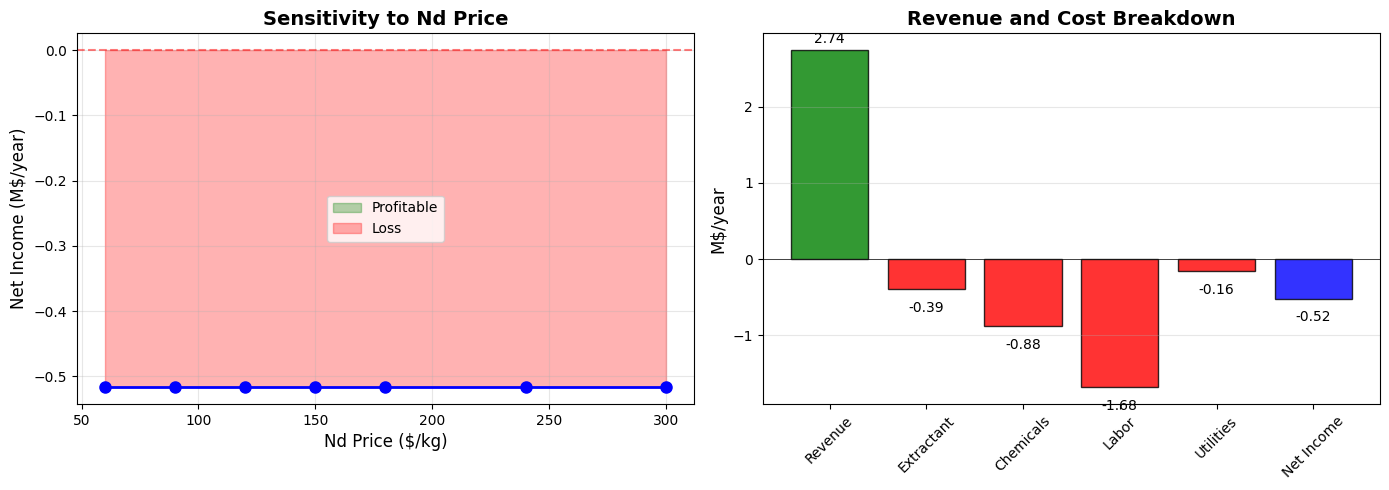

In [11]:
# Profit sensitivity plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Nd price sensitivity
ax1 = axes[0]
nd_prices = [60, 90, 120, 150, 180, 240, 300]
net_incomes = []
rois = []

base_nd_price = pricing.get_price("Nd", "99%", "oxide") * 0.8
nd_mass_yr = float(prod_flows.get("Nd", 0)) * get_element("Nd").atomic_weight * 3600 * 8000 / 1000

for nd_price in nd_prices:
    revenue_adj = total_revenue + nd_mass_yr * (nd_price - base_nd_price)
    profit_adj = calculate_profit(revenue=revenue_adj, opex=opex["total"], capex=capex["total"])
    net_incomes.append(profit_adj['net_income']/1e6)
    rois.append(profit_adj['roi']*100)

ax1.plot(nd_prices, net_incomes, 'b-o', linewidth=2, markersize=8)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax1.fill_between(nd_prices, net_incomes, 0, where=[n > 0 for n in net_incomes], 
                  alpha=0.3, color='green', label='Profitable')
ax1.fill_between(nd_prices, net_incomes, 0, where=[n <= 0 for n in net_incomes],
                  alpha=0.3, color='red', label='Loss')
ax1.set_xlabel('Nd Price ($/kg)', fontsize=12)
ax1.set_ylabel('Net Income (M$/year)', fontsize=12)
ax1.set_title('Sensitivity to Nd Price', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Right: Waterfall chart of costs and revenues
ax2 = axes[1]
categories = ['Revenue', 'Extractant', 'Chemicals', 'Labor', 'Utilities', 'Net Income']
values = [
    total_revenue/1e6,
    -opex.get('extractant', 0)/1e6,
    -(opex.get('acid', 0) + opex.get('base', 0) + opex.get('precipitant', 0))/1e6,
    -opex.get('labor', 0)/1e6,
    -(opex.get('utilities', 0) + opex.get('maintenance', 0))/1e6,
    profit['net_income']/1e6,
]

colors = ['green' if v > 0 else 'red' for v in values]
colors[-1] = 'blue'  # Net income in blue

ax2.bar(categories, values, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('M$/year', fontsize=12)
ax2.set_title('Revenue and Cost Breakdown', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(values):
    ax2.text(i, v + 0.1 if v >= 0 else v - 0.3, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis: What Would Make This Profitable?

In [12]:
print("Break-Even Analysis")
print("=" * 60)

# What Nd price is needed for break-even?
# Net income = Revenue - OPEX - Depreciation - Tax
# For break-even: Revenue = OPEX + Depreciation (assuming no tax on zero profit)
required_revenue = opex["total"] + profit['depreciation']
revenue_gap = required_revenue - total_revenue

print(f"\nCurrent revenue: ${total_revenue/1e6:.2f} M/year")
print(f"Required for break-even: ${required_revenue/1e6:.2f} M/year")
print(f"Revenue gap: ${revenue_gap/1e6:.2f} M/year")

if nd_mass_yr > 0:
    additional_nd_price = revenue_gap / nd_mass_yr
    breakeven_nd_price = base_nd_price + additional_nd_price
    print(f"\nNd production: {nd_mass_yr:.0f} kg/year")
    print(f"Current Nd price (80% of oxide): ${base_nd_price:.0f}/kg")
    print(f"Break-even Nd price needed: ${breakeven_nd_price:.0f}/kg")
    
    if breakeven_nd_price > 0:
        print(f"\n-> Nd price needs to increase {(breakeven_nd_price/base_nd_price - 1)*100:.0f}% for break-even")

# Alternative: scale up plant
print("\n" + "=" * 60)
print("Scale-up analysis: How big does plant need to be?")
print("=" * 60)

# Assume OPEX scales ~70% with capacity (labor is fixed)
# Revenue scales 100% with capacity
for scale in [2, 3, 5, 10]:
    scaled_revenue = total_revenue * scale
    scaled_opex = (opex['labor'] + 
                   (opex['total'] - opex['labor']) * scale)
    scaled_capex = capex['total'] * (scale ** 0.6)  # 0.6 power scaling
    
    scaled_profit = calculate_profit(
        revenue=scaled_revenue,
        opex=scaled_opex,
        capex=scaled_capex,
    )
    
    print(f"\n{scale}x scale ({annual_tonnes*scale:.0f} t/yr):")
    print(f"  Revenue: ${scaled_revenue/1e6:.1f}M, OPEX: ${scaled_opex/1e6:.1f}M, CAPEX: ${scaled_capex/1e6:.1f}M")
    print(f"  Net Income: ${scaled_profit['net_income']/1e6:.1f}M, ROI: {scaled_profit['roi']*100:.0f}%")

Break-Even Analysis

Current revenue: $2.74 M/year
Required for break-even: $3.26 M/year
Revenue gap: $0.52 M/year

Nd production: 0 kg/year
Current Nd price (80% of oxide): $96/kg
Break-even Nd price needed: $2252838774866486493184/kg

-> Nd price needs to increase 2346707057152590348288% for break-even

Scale-up analysis: How big does plant need to be?

2x scale (391 t/yr):
  Revenue: $5.5M, OPEX: $4.5M, CAPEX: $2.3M
  Net Income: $0.5M, ROI: 24%

3x scale (586 t/yr):
  Revenue: $8.2M, OPEX: $6.0M, CAPEX: $2.9M
  Net Income: $1.5M, ROI: 51%

5x scale (976 t/yr):
  Revenue: $13.7M, OPEX: $8.8M, CAPEX: $4.0M
  Net Income: $3.4M, ROI: 85%

10x scale (1953 t/yr):
  Revenue: $27.4M, OPEX: $16.0M, CAPEX: $6.0M
  Net Income: $8.1M, ROI: 136%


## Summary

This notebook demonstrated a **simplified bastnasite REE separation flowsheet**:

### Process Design
- Single extract-scrub-strip circuit using PC88A
- Produces two concentrates: La/Ce and Didymium (Pr/Nd)
- No Ce removal or multi-stage group separation needed

### Key Insights
1. **Small plants are not economical** - Labor costs dominate at small scale
2. **REE prices matter** - Project viability is very sensitive to Nd price
3. **Scale is critical** - Need >1000 t/year to achieve reasonable ROI
4. **Selling concentrates vs oxides** - Lower capex but lower margins

### What Would Make It Profitable?
- Higher Nd prices (>$150/kg)
- Larger plant scale (>5x current)
- Lower labor costs (automation)
- Integration with mining operation (shared infrastructure)